# GARCH + GEV Block Maxima — VaR для S&P 500 и NIKKEI 225

Реализация метода блочных максимумов (формулы 37–45 из диплома) на реальных данных за 20 лет.

**Метод:**
1. Оцениваем GARCH(1,1) → стандартизированные остатки $\hat{z}_t$
2. Берём $-\hat{z}_t$ (убытки) и делим на блоки длины $N$ → блочные максимумы $M_k^{(N)}$
3. Фиттим GEV → $(\hat{\mu}, \hat{\sigma}, \hat{\xi})$
4. Квантильная оценка: $Q_{1-\alpha} = \hat{\sigma}_{T+1} \cdot H^{-1}_{\hat{\mu},\hat{\sigma},\hat{\xi}}((1-\alpha)^N)$

**Формула обратной функции GEV (ур. 43/44):**
$$H^{-1}((1-\alpha)^N) = \hat{\mu} + \frac{\hat{\sigma}}{\hat{\xi}}\left([-N \ln(1-\alpha)]^{-\hat{\xi}} - 1\right), \quad \hat{\xi} \neq 0$$
$$H^{-1}((1-\alpha)^N) = \hat{\mu} - \hat{\sigma} \ln[-N \ln(1-\alpha)], \quad \hat{\xi} = 0$$

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from scipy.optimize import minimize
from scipy.stats import genextreme, norm, skew, kurtosis
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

## 1. Загрузка данных

In [15]:
TICKERS = {"S&P 500": "^GSPC", "NIKKEI 225": "^N225"}
START, END = "2005-01-01", "2025-06-01"

prices = {}
for name, ticker in TICKERS.items():
    raw = yf.Ticker(ticker).history(start=START, end=END)
    close = raw["Close"].dropna()
    close = close[close > 0]
    prices[name] = close
    print(f"{name}: {len(close)} торговых дней ({close.index[0].date()} — {close.index[-1].date()})")

S&P 500: 5135 торговых дней (2005-01-03 — 2025-05-30)
NIKKEI 225: 4993 торговых дней (2005-01-04 — 2025-05-30)


In [16]:
returns = {}
for name, close in prices.items():
    r = close.pct_change().dropna()
    returns[name] = r
    print(f"{name}: {len(r)} наблюдений доходностей")

S&P 500: 5134 наблюдений доходностей
NIKKEI 225: 4992 наблюдений доходностей


## 2. Разведочный анализ

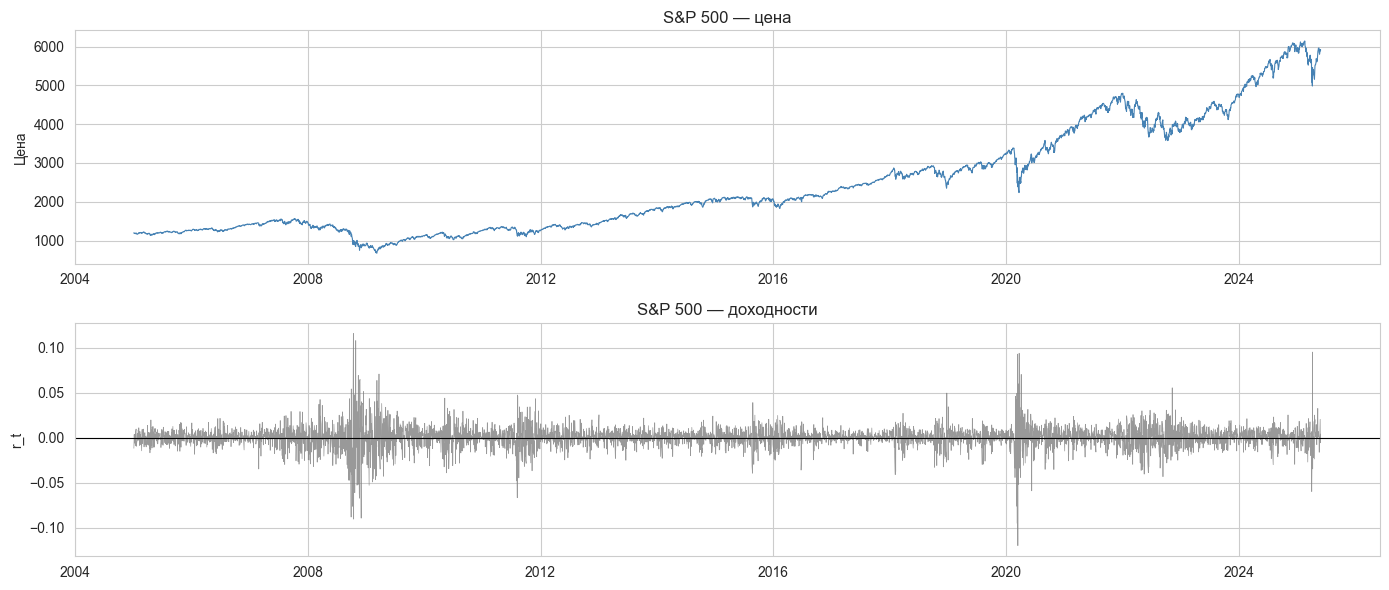

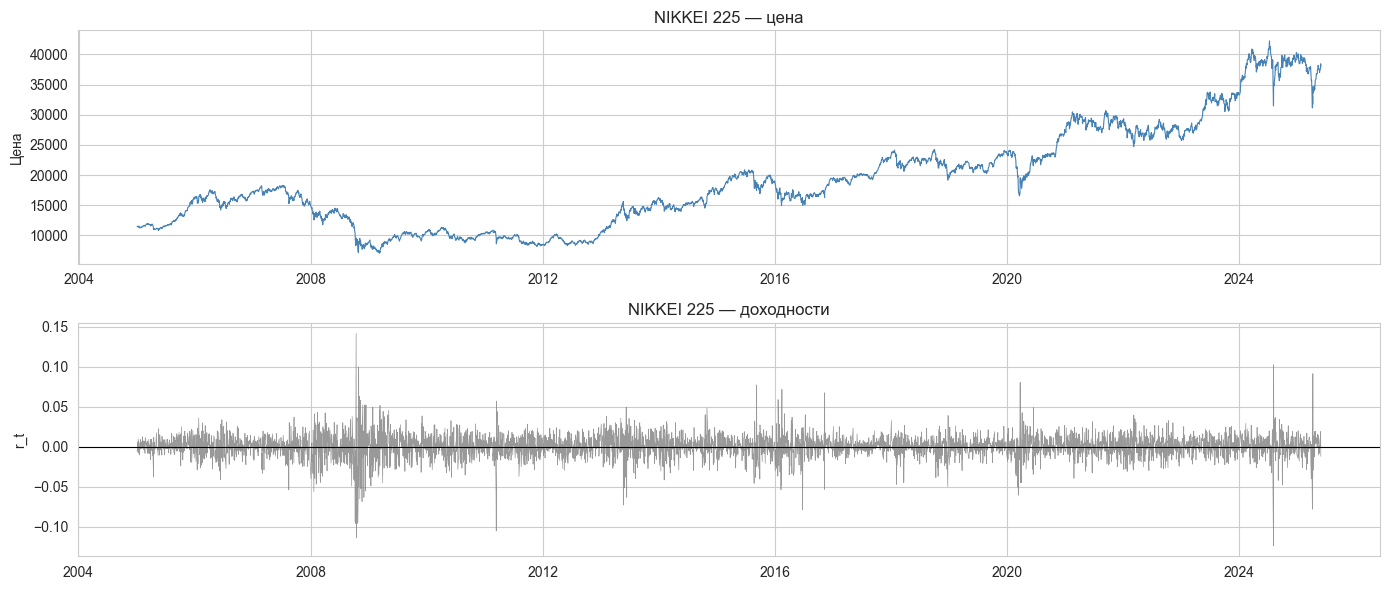

In [17]:
for name, close in prices.items():
    r = returns[name]
    fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=False)

    axes[0].plot(close.index, close.values, linewidth=0.8, color='steelblue')
    axes[0].set_title(f'{name} — цена')
    axes[0].set_ylabel('Цена')

    axes[1].plot(r.index, r.values, linewidth=0.5, color='gray', alpha=0.8)
    axes[1].axhline(0, color='black', linewidth=0.8)
    axes[1].set_title(f'{name} — доходности')
    axes[1].set_ylabel('r_t')

    plt.tight_layout()
    plt.show()

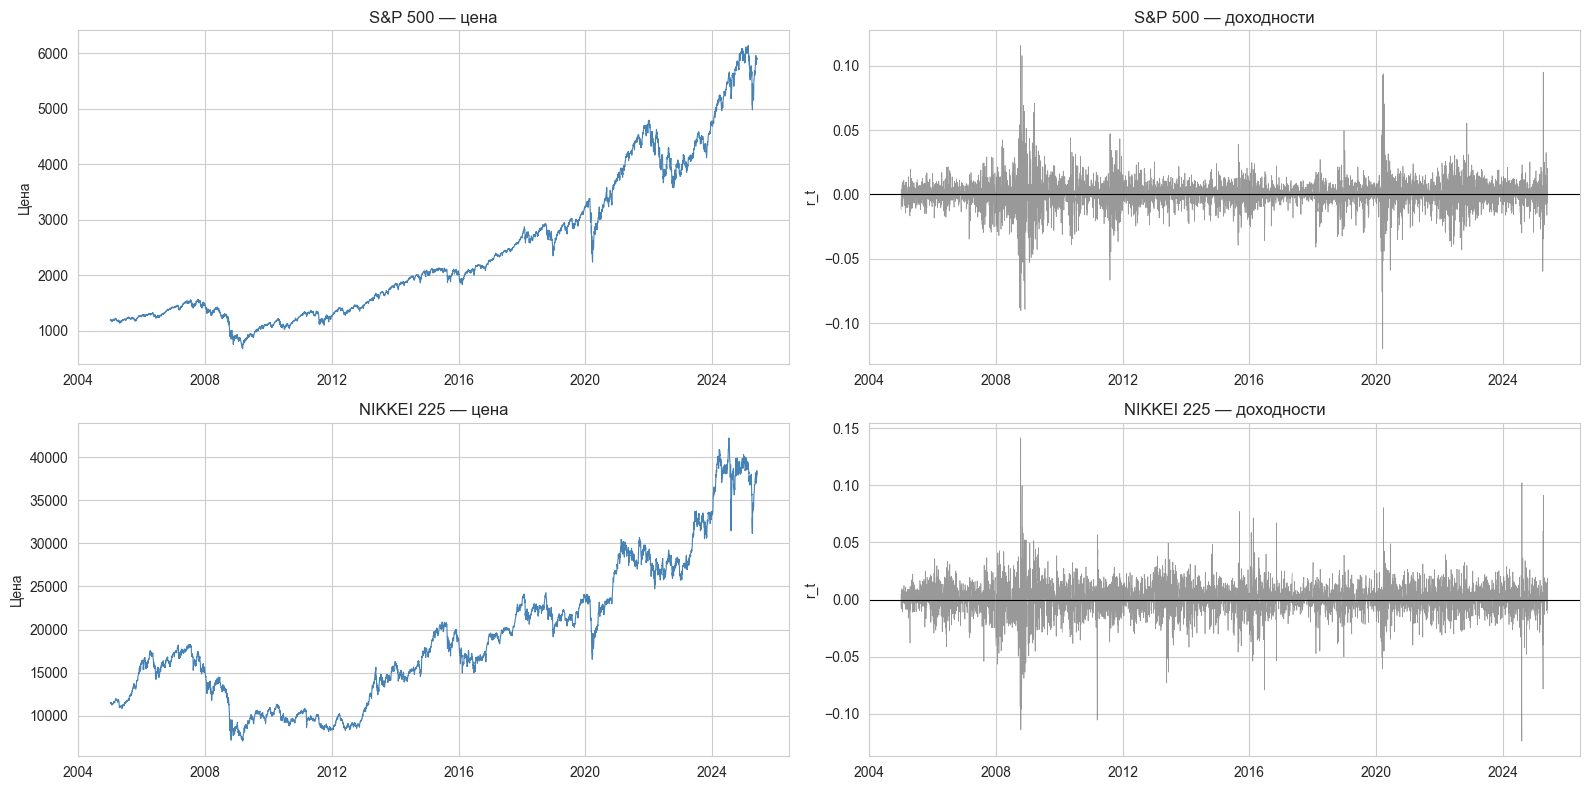

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))

for i, (name, close) in enumerate(prices.items()):
    r = returns[name]
    axes[i, 0].plot(close.index, close.values, linewidth=0.8, color='steelblue')
    axes[i, 0].set_title(f'{name} — цена')
    axes[i, 0].set_ylabel('Цена')
    axes[i, 1].plot(r.index, r.values, linewidth=0.5, color='gray', alpha=0.8)
    axes[i, 1].axhline(0, color='black', linewidth=0.8)
    axes[i, 1].set_title(f'{name} — доходности')
    axes[i, 1].set_ylabel('r_t')

plt.tight_layout()
plt.show()

## 3. GARCH(1,1) — оценка по ММП с масштабированием

In [19]:
def scaling_estimate_garch11_norm(x):
    """
    GARCH(1,1) QMLE с масштабированием x100 для численной стабильности.
    Возвращает dict: omega, alpha, beta, loglik, sigmas (в исходном масштабе).
    """
    x = np.asarray(x * 100, dtype=float)
    n = len(x)
    var_x = np.var(x)

    def compute_variances(params):
        omega, alpha, beta = params
        h = np.empty(n, dtype=float)
        denom = 1.0 - alpha - beta
        if denom <= 0:
            return None
        h0 = omega / denom
        if h0 <= 0 or not np.isfinite(h0):
            return None
        h[0] = h0
        for t in range(1, n):
            h[t] = omega + alpha * x[t - 1] ** 2 + beta * h[t - 1]
            if h[t] <= 0 or not np.isfinite(h[t]):
                return None
        return h

    def neg_loglik(params):
        omega, alpha, beta = params
        if omega <= 0 or alpha < 0 or beta < 0 or alpha + beta >= 1:
            return 1e20
        h = compute_variances(params)
        if h is None:
            return 1e20
        ll = -0.5 * np.sum(np.log(2.0 * np.pi) + np.log(h) + (x ** 2) / h)
        return -ll

    alpha0, beta0 = 0.2, 0.3
    omega0 = max(var_x * (1.0 - alpha0 - beta0), 1e-8)
    x0 = np.array([omega0, alpha0, beta0])
    bounds = [(1e-12, None), (0.0, 1.0), (0.0, 1.0)]

    result = minimize(neg_loglik, x0, method="L-BFGS-B", bounds=bounds)
    omega_hat, alpha_hat, beta_hat = result.x
    sigma_hat = compute_variances((omega_hat, alpha_hat, beta_hat)) ** 0.5 / 100

    return {
        "omega": float(omega_hat) / 100 ** 2,
        "alpha": float(alpha_hat),
        "beta": float(beta_hat),
        "loglik": float(-result.fun),
        "sigmas": sigma_hat,
    }

## 4. Вспомогательные функции

In [ ]:
def block_maxima(arr, n):
    """Делит arr на блоки длины n, возвращает максимум каждого блока."""
    arr = np.asarray(arr)
    num_blocks = len(arr) // n
    trimmed = arr[:num_blocks * n]
    return trimmed.reshape(num_blocks, n).max(axis=1)


def gev_quantile_bm(alpha, N, mu, sigma, xi):
    """
    Вычисляет H^{-1}((1-alpha)^N) — квантиль уровня (1-alpha)^N распределения GEV(mu, sigma, xi).

    Реализует формулы (43)/(44) из диплома:
      xi != 0:  mu + (sigma/xi) * ([-N*log(1-alpha)]^(-xi) - 1)
      xi == 0:  mu - sigma * log(-N*log(1-alpha))               (предел Гумбеля)

    Знаковое соглашение: работаем с убытками loss = -z_t, поэтому
    возвращаемый q > 0 (квантиль правого хвоста убытков).
    VaR в пространстве доходностей = -sigma_{T+1} * q.
    """
    inner = -N * np.log(1 - alpha)  
    if abs(xi) < 1e-6:
        return mu - sigma * np.log(inner)
    return mu + (sigma / xi) * (inner ** (-xi) - 1)


S&P 500:
  GARCH: omega=0.0000338, alpha=0.6172, beta=0.3301
  GEV (N=63, K=81 блоков): xi=0.0404, mu=2.1063, sigma_gev=0.7642
  alpha=0.01: VaR(GEV)=-0.0199  VaR(vanilla)=-0.0188
  alpha=0.005: VaR(GEV)=-0.0244  VaR(vanilla)=-0.0209

NIKKEI 225:
  GARCH: omega=0.0000647, alpha=0.4474, beta=0.3510
  GEV (N=63, K=79 блоков): xi=0.0304, mu=2.1195, sigma_gev=0.6221
  alpha=0.01: VaR(GEV)=-0.0359  VaR(vanilla)=-0.0347
  alpha=0.005: VaR(GEV)=-0.0426  VaR(vanilla)=-0.0385


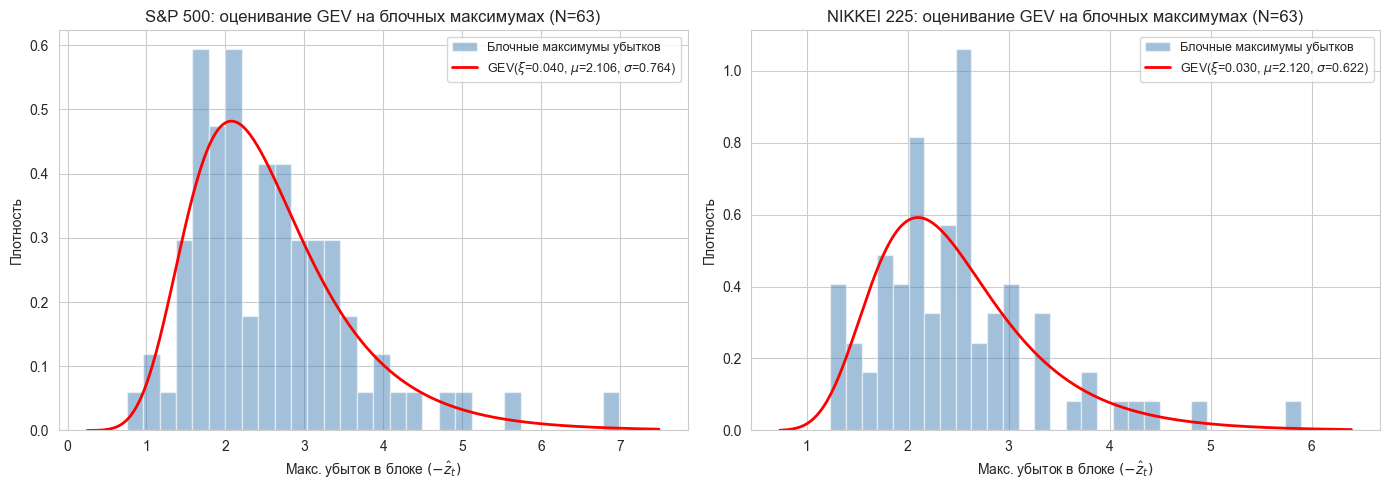

In [ ]:
BLOCK_SIZE = 63  
ALPHAS = [0.01, 0.005]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, r) in zip(axes, returns.items()):
    r_arr = r.values

    res = scaling_estimate_garch11_norm(r_arr)
    sigmas = res['sigmas']
    losses = -(r_arr / sigmas)   # убытки: положительный = плохой исход
    maxima = block_maxima(losses, BLOCK_SIZE)

    c_hat, loc_hat, scale_hat = genextreme.fit(maxima)  # scipy: c = -xi
    xi_hat = -c_hat

    sigma_next = np.sqrt(res['omega'] + res['alpha'] * r_arr[-1]**2 + res['beta'] * sigmas[-1]**2)

    print(f"\n{name}:")
    print(f"  GARCH: omega={res['omega']:.7f}, alpha={res['alpha']:.4f}, beta={res['beta']:.4f}")
    print(f"  GEV (N={BLOCK_SIZE}, K={len(maxima)} блоков): xi={xi_hat:.4f}, mu={loc_hat:.4f}, sigma_gev={scale_hat:.4f}")
    for alpha in ALPHAS:
        q = gev_quantile_bm(alpha, BLOCK_SIZE, loc_hat, scale_hat, xi_hat)
        var_gev     = -sigma_next * q
        var_vanilla = sigma_next * norm.ppf(alpha)
        print(f"  alpha={alpha}: VaR(GEV)={var_gev:.4f}  VaR(vanilla)={var_vanilla:.4f}")

    x_grid = np.linspace(maxima.min() - 0.5, maxima.max() + 0.5, 300)
    ax.hist(maxima, bins=30, density=True, alpha=0.5, color='steelblue',
            label='Блочные максимумы убытков')
    ax.plot(x_grid, genextreme.pdf(x_grid, c_hat, loc_hat, scale_hat),
            color='red', lw=2,
            label=f'GEV($\\xi$={xi_hat:.3f}, $\\mu$={loc_hat:.3f}, $\\sigma$={scale_hat:.3f})')
    ax.set_title(f'{name}: оценивание GEV на блочных максимумах (N={BLOCK_SIZE})')
    ax.set_xlabel('Макс. убыток в блоке $(-\\hat{z}_t)$')
    ax.set_ylabel('Плотность')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 7. QQ-plot: проверка качества GEV-фита

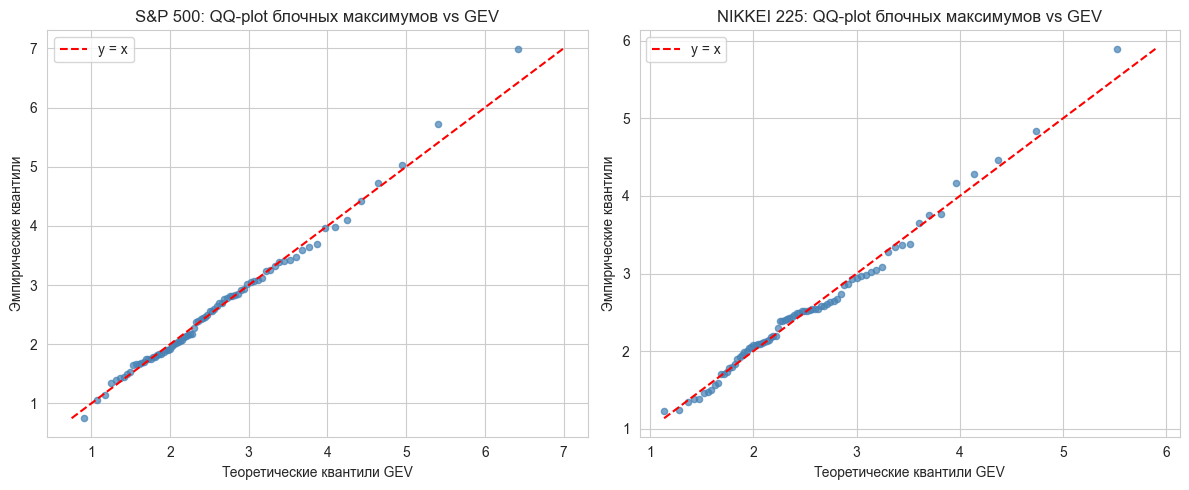

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, r) in zip(axes, returns.items()):
    r_arr = r.values
    res = scaling_estimate_garch11_norm(r_arr)
    losses = -(r_arr / res['sigmas'])
    maxima = block_maxima(losses, BLOCK_SIZE)

    c_hat, loc_hat, scale_hat = genextreme.fit(maxima)
    n = len(maxima)
    probs = (np.arange(1, n + 1) - 0.5) / n
    emp_q = np.sort(maxima)
    theo_q = genextreme.ppf(probs, c_hat, loc_hat, scale_hat)

    ax.scatter(theo_q, emp_q, s=20, alpha=0.7, color='steelblue')
    lims = [min(theo_q.min(), emp_q.min()), max(theo_q.max(), emp_q.max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='y = x')
    ax.set_xlabel('Теоретические квантили GEV')
    ax.set_ylabel('Эмпирические квантили')
    ax.set_title(f'{name}: QQ-plot блочных максимумов vs GEV')
    ax.legend()

plt.tight_layout()
plt.show()

## 8. Скользящая оценка VaR: Vanilla GARCH vs GARCH+GEV

Параметры: `window=1000` (~4 года, даёт ~15 квартальных блоков для GEV-фита), `N=63`.

In [23]:
def rolling_garch_gev_var(r, window=1000, alpha=0.01, block_size=63):
    """
    Скользящая оценка VaR двумя методами.

    Возвращает var_vanilla, var_gev — массивы длины len(r)+1:
      var_vanilla[t] = sigma_{t+1} * Phi^{-1}(alpha)           (Vanilla GARCH)
      var_gev[t]     = -sigma_{t+1} * H^{-1}((1-alpha)^N)      (GARCH + GEV, eq.43/44)
    Оба отрицательны (нижняя граница доходности).
    NaN для t < window.
    """
    r = np.asarray(r, dtype=float)
    n = len(r)
    var_vanilla = np.full(n + 1, np.nan)
    var_gev = np.full(n + 1, np.nan)
    z_norm = norm.ppf(alpha)

    for t in range(window, n + 1):
        r_win = r[t - window:t]

        res = scaling_estimate_garch11_norm(r_win)
        omega_h, alpha_h, beta_h = res['omega'], res['alpha'], res['beta']
        sigmas = res['sigmas']
        sigma_next = np.sqrt(omega_h + alpha_h * r_win[-1]**2 + beta_h * sigmas[-1]**2)

        var_vanilla[t] = sigma_next * z_norm

        losses = -(r_win / sigmas)
        try:
            maxima = block_maxima(losses, block_size)
            c_hat, loc_hat, scale_hat = genextreme.fit(maxima)
            xi_hat = -c_hat
            q = gev_quantile_bm(alpha, block_size, loc_hat, scale_hat, xi_hat)
            var_gev[t] = -sigma_next * q
        except Exception:
            var_gev[t] = np.nan

    return var_vanilla, var_gev

In [24]:
WINDOW = 1000

results = {}
for name, r in returns.items():
    r_arr = r.values
    print(f"\n{name} ({len(r_arr)} наблюдений, window={WINDOW}):")
    all_alphas = {}
    for alpha in ALPHAS:
        print(f"  alpha={alpha}...", end=" ", flush=True)
        var_v, var_g = rolling_garch_gev_var(r_arr, window=WINDOW, alpha=alpha, block_size=BLOCK_SIZE)
        all_alphas[alpha] = {'vanilla': var_v, 'gev': var_g}
        print("готово")
    results[name] = {'returns': r_arr, 'dates': r.index, 'vars': all_alphas}

print("\nВсе оценки завершены.")


S&P 500 (5134 наблюдений, window=1000):
  alpha=0.01... готово
  alpha=0.005... готово

NIKKEI 225 (4992 наблюдений, window=1000):
  alpha=0.01... готово
  alpha=0.005... готово

Все оценки завершены.


## 10. Визуализация: доходности и VaR-полосы

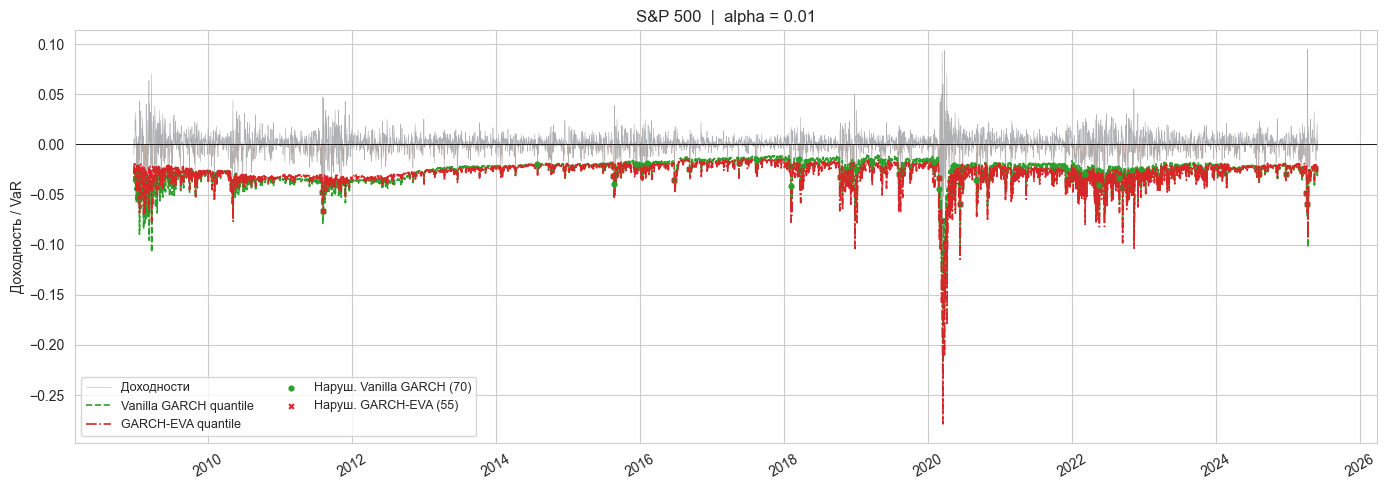

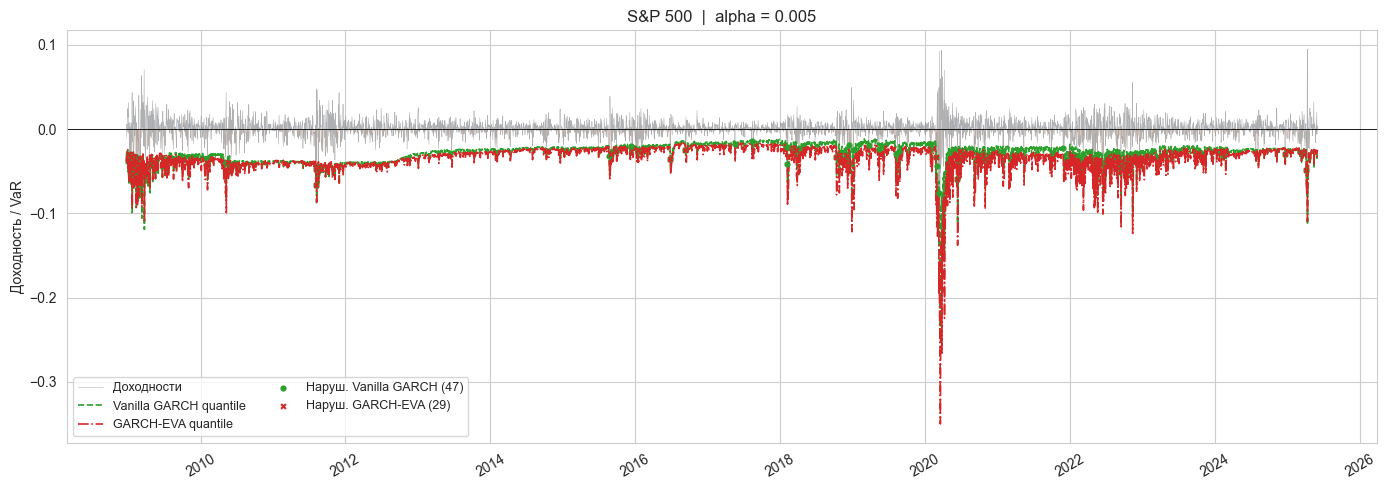

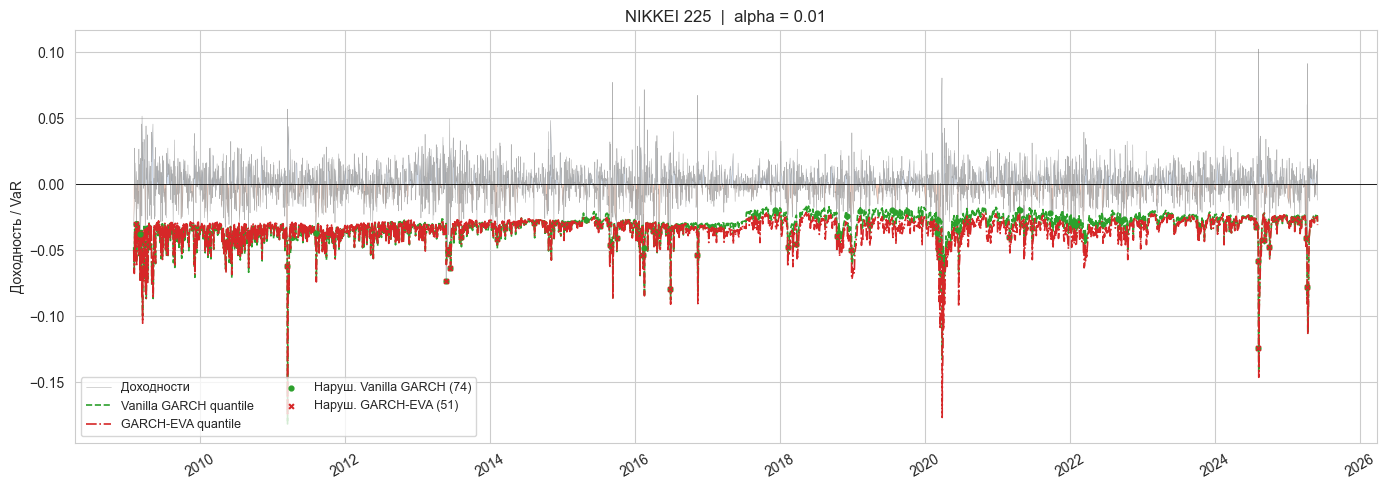

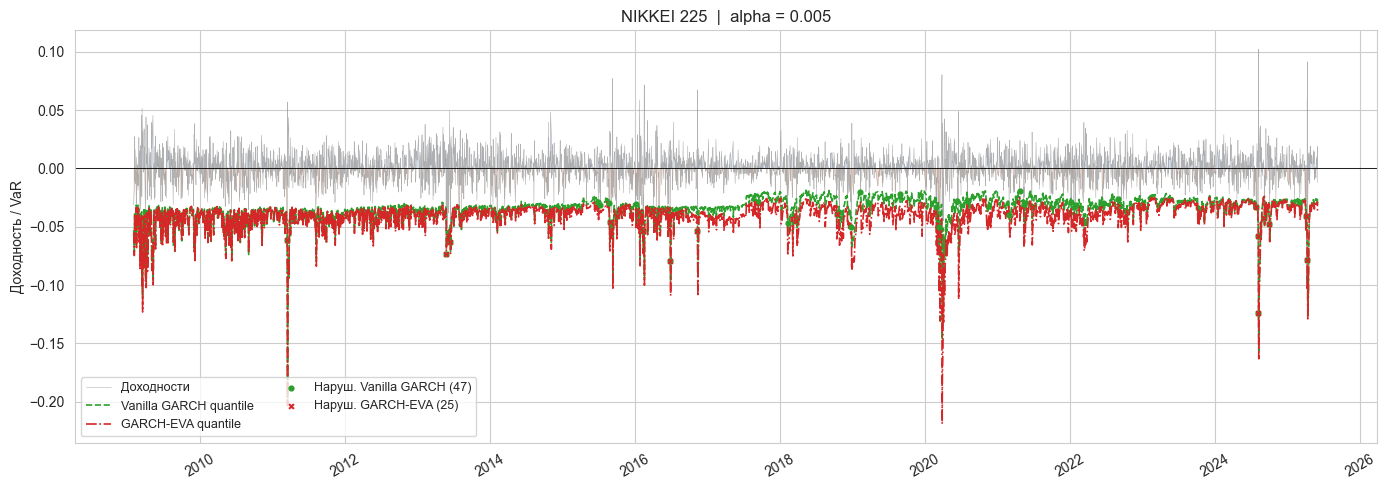

In [35]:
for name, res_dict in results.items():
    r_arr = res_dict['returns']
    dates = res_dict['dates']
    test_idx = np.arange(WINDOW, len(r_arr))
    test_dates = dates[test_idx]
    r_test = r_arr[test_idx]

    for alpha in ALPHAS:
        fig, ax = plt.subplots(figsize=(14, 5))

        var_v = res_dict['vars'][alpha]['vanilla'][test_idx]
        var_g = res_dict['vars'][alpha]['gev'][test_idx]

        ax.fill_between(test_dates, r_test, 0, where=(r_test >= 0), color='#aec6e8', alpha=0.5, linewidth=0)
        ax.fill_between(test_dates, r_test, 0, where=(r_test < 0),  color='#f4a582', alpha=0.5, linewidth=0)
        ax.plot(test_dates, r_test, color='grey', linewidth=0.4, alpha=0.6, label='Доходности')

        ax.plot(test_dates, var_v, color='#2ca02c', linewidth=1.2, linestyle='--', label='Vanilla GARCH quantile')
        ax.plot(test_dates, var_g, color='#d62728', linewidth=1.2, linestyle='-.', label='GARCH-EVA quantile')

        mask_v = ~np.isnan(var_v) & (r_test < var_v)
        mask_g = ~np.isnan(var_g) & (r_test < var_g)
        ax.scatter(test_dates[mask_v], r_test[mask_v], color='#2ca02c', s=12, zorder=5, label=f'Наруш. Vanilla GARCH ({mask_v.sum()})')
        ax.scatter(test_dates[mask_g], r_test[mask_g], color='#d62728', s=12, marker='x', zorder=5, label=f'Наруш. GARCH-EVA ({mask_g.sum()})')

        ax.axhline(0, color='black', linewidth=0.6)
        ax.set_title(f'{name}  |  alpha = {alpha}', fontsize=12)
        ax.set_ylabel('Доходность / VaR')
        ax.legend(fontsize=9, loc='lower left', ncol=2)
        ax.tick_params(axis='x', labelrotation=30)

        plt.tight_layout()
        plt.show()

In [29]:
print(f"{'Индекс':12s} {'alpha':7s} {'Метод':12s} {'Нарушений':10s} {'Доля,%':8s} {'Номин.,%':8s}")
print("-" * 57)

for name, res_dict in results.items():
    r_arr = res_dict['returns']
    for alpha in ALPHAS:
        var_v = res_dict['vars'][alpha]['vanilla']
        var_g = res_dict['vars'][alpha]['gev']
        r_test     = r_arr[WINDOW:]
        var_v_test = var_v[WINDOW:len(r_arr)]
        var_g_test = var_g[WINDOW:len(r_arr)]

        for method_name, var_arr in [("Vanilla", var_v_test), ("GARCH+GEV", var_g_test)]:
            mask = ~np.isnan(var_arr)
            r_valid = r_test[mask]
            v_valid = var_arr[mask]
            T = len(r_valid)
            n_viol = int((r_valid < v_valid).sum())
            share = n_viol / T * 100
            print(f"{name:12s} {alpha:<7.4f} {method_name:12s} {n_viol:<10d} {share:<8.2f} {alpha*100:<8.2f}")

Индекс       alpha   Метод        Нарушений  Доля,%   Номин.,%
---------------------------------------------------------
S&P 500      0.0100  Vanilla      70         1.69     1.00    
S&P 500      0.0100  GARCH+GEV    55         1.33     1.00    
S&P 500      0.0050  Vanilla      47         1.14     0.50    
S&P 500      0.0050  GARCH+GEV    29         0.70     0.50    
NIKKEI 225   0.0100  Vanilla      74         1.85     1.00    
NIKKEI 225   0.0100  GARCH+GEV    51         1.28     1.00    
NIKKEI 225   0.0050  Vanilla      47         1.18     0.50    
NIKKEI 225   0.0050  GARCH+GEV    25         0.63     0.50    


## 11. Сравнение: реализованные vs номинальные доли нарушений

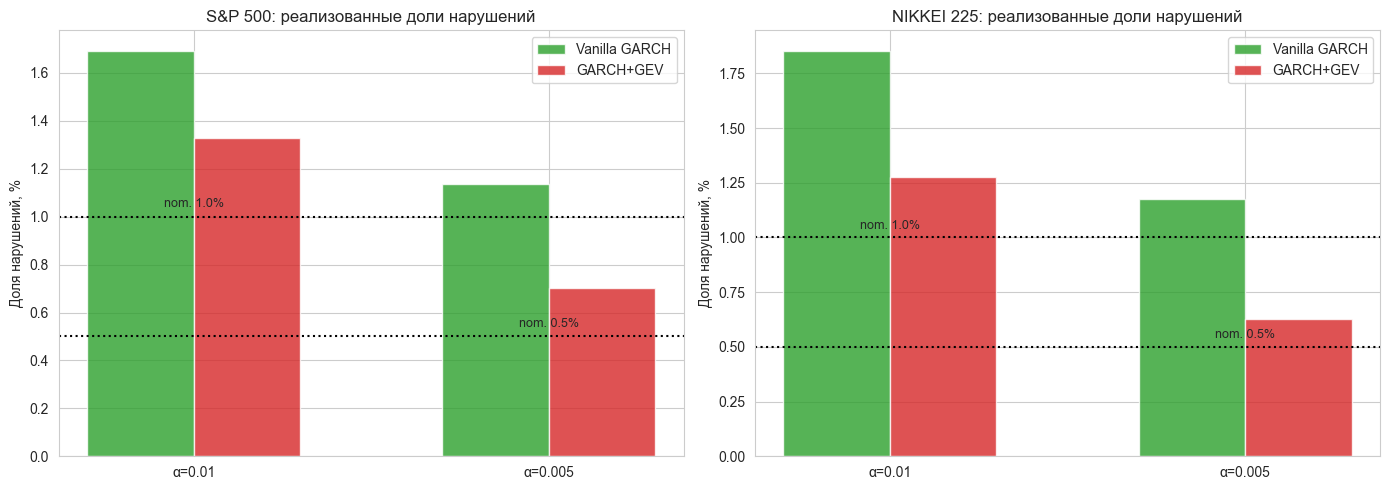

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, res_dict) in zip(axes, results.items()):
    r_arr = res_dict['returns']
    x = np.arange(len(ALPHAS))
    width = 0.3

    for j, (key, label, color) in enumerate([
        ('vanilla', 'Vanilla GARCH', '#2ca02c'),
        ('gev',     'GARCH+GEV',    '#d62728'),
    ]):
        shares = []
        for alpha in ALPHAS:
            var_arr = res_dict['vars'][alpha][key]
            r_test = r_arr[WINDOW:]
            v_test = var_arr[WINDOW:len(r_arr)]
            mask = ~np.isnan(v_test)
            share = (r_test[mask] < v_test[mask]).mean() * 100
            shares.append(share)
        ax.bar(x + j * width, shares, width, label=label, color=color, alpha=0.8)

    for i, alpha in enumerate(ALPHAS):
        ax.axhline(alpha * 100, color='black', linestyle=':', linewidth=1.5)
        ax.text(i + width / 2, alpha * 100 + 0.04,
                f'nom. {alpha*100:.1f}%', ha='center', fontsize=9)

    ax.set_xticks(x + width / 2)
    ax.set_xticklabels([f'α={a}' for a in ALPHAS])
    ax.set_ylabel('Доля нарушений, %')
    ax.set_title(f'{name}: реализованные доли нарушений')
    ax.legend()

plt.tight_layout()
plt.show()